In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [8]:
df_index=pd.read_csv("mul_lin_reg.csv")
df_index.head()

,Unnamed: 0,Year,Month,Interest Rate,Unemployment Rate,Index Price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [9]:
df_index.drop(columns=["Unnamed: 0","Year","Month"],axis=1,inplace=True)

In [10]:
df_index.head()

,Interest Rate,Unemployment Rate,Index Price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [11]:
df_index.isnull().sum()

Interest Rate        0
Unemployment Rate    0
Index Price          0
dtype: int64

In [12]:
import seaborn as sns

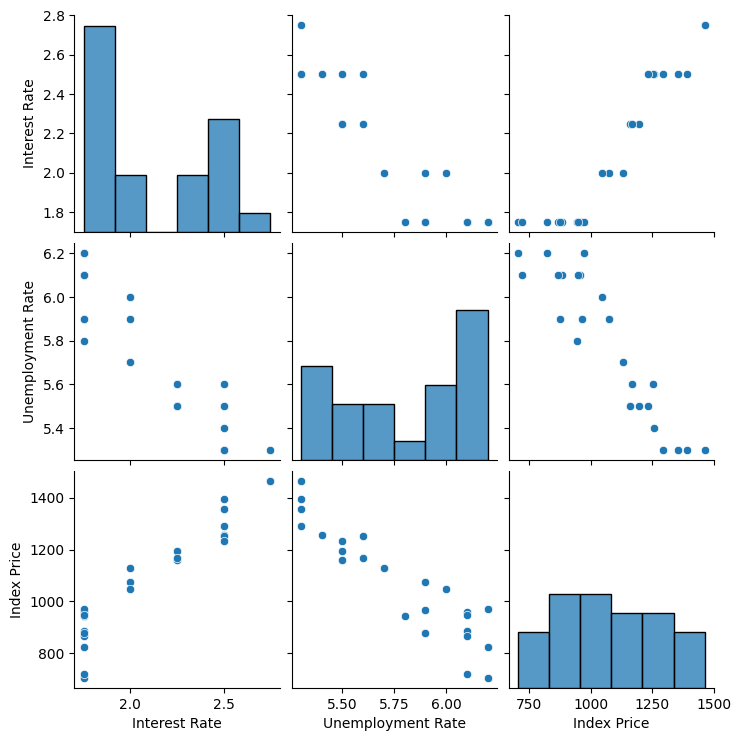

In [13]:
sns.pairplot(df_index)

In [14]:
df_index.corr()

,Interest Rate,Unemployment Rate,Index Price
Interest Rate,1.000000,-0.925814,0.935793
Unemployment Rate,-0.925814,1.000000,-0.922338
Index Price,0.935793,-0.922338,1.000000


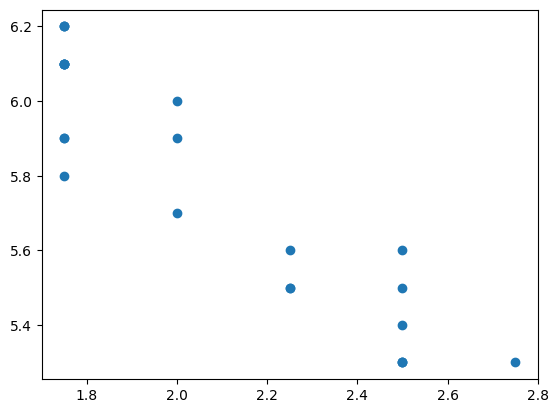

In [15]:
plt.scatter(df_index['Interest Rate'],df_index['Unemployment Rate'])

In [21]:
X=df_index[["Interest Rate","Unemployment Rate"]]
y=df_index[["Index Price"]]


In [22]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,t_test=train_test_split(X,y,test_size=0.25,random_state=42)


<Axes: xlabel='Interest Rate', ylabel='Index Price'>

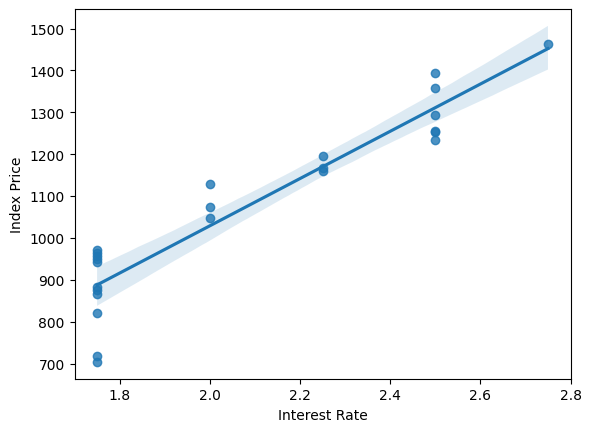

In [24]:
sns.regplot(x=df_index['Interest Rate'],y=df_index['Index Price'])

<Axes: xlabel='Interest Rate', ylabel='Unemployment Rate'>

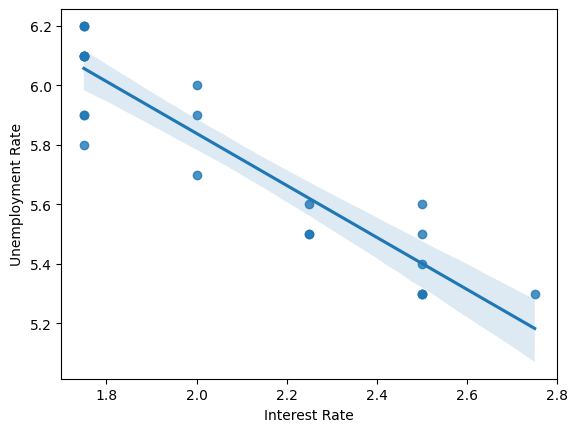

In [25]:
sns.regplot(x=df_index['Interest Rate'],y=df_index['Unemployment Rate'])

In [26]:
from sklearn.preprocessing import StandardScaler

In [27]:
scalre=StandardScaler()
X_train=scalre.fit_transform(X_train)
X_test=scalre.fit_transform(X_test)

In [29]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()

In [30]:
regression.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [31]:
from sklearn.model_selection import cross_val_score
validation_score=cross_val_score(regression,X_train,y_train,scoring="neg_mean_squared_error",cv=3)

In [33]:
np.mean(validation_score)

np.float64(-5914.8281801623925)

In [35]:
y_pred=regression.predict(X_test)
y_pred

array([[1180.7466813 ],
       [ 802.74279699],
       [1379.83457045],
       [ 838.52599602],
       [ 973.85313963],
       [1144.96348227]])